# Feature Extraction Pipeline — HOG + CNN Representation

This notebook prepares image features for the waste classification models. The final representation combines two complementary descriptors:

- **CNN features** extracted from a pretrained ResNet50 backbone with global average pooling.
- **HOG features** that capture edge direction and object shape information.
- **Train-only scaling**, where all preprocessing objects are fitted only on the training split.
- **Combined feature vectors**, saved in the same filenames expected by the classifier notebooks.

The notebook reads from the prepared dataset split:

- `../data_split/train_aug`
- `../data_split/val`
- `../data_split/test`

The generated files are saved in:

- `../features`
- `../models`

The main classifier inputs are overwritten as:

- `../features/X_train_scaled.npy`
- `../features/X_val_scaled.npy`
- `../features/X_test_scaled.npy`

In this version, these three files contain the final scaled **HOG + CNN** feature matrix.


## Required Libraries


In [26]:
import os
import json
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter
from tqdm import tqdm

from skimage.feature import hog
from skimage import exposure
from sklearn.preprocessing import Normalizer, StandardScaler, LabelEncoder

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

from skimage.feature import hog as hog_visualizer

## Configuration and Project Paths


In [27]:
# Main image size used by the ResNet50 branch.
CNN_IMAGE_SIZE = (224, 224)  # format: (height, width)

# HOG uses the same image size to keep the feature extraction setup consistent.
# A smaller size such as (128, 128) can be tested later as an ablation experiment.
HOG_IMAGE_SIZE = (224, 224)

# HOG configuration used for the shape/edge descriptor.
HOG_PARAMS = {
    "orientations": 9,
    "pixels_per_cell": (8, 8),
    "cells_per_block": (2, 2),
    "block_norm": "L2-Hys"
}

IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
EXPECTED_CLASSES = {"cardboard", "glass", "metal", "paper", "plastic", "trash"}

# Project folder layout.
TRAIN_PATH = Path("../data_split/train_aug")
VAL_PATH   = Path("../data_split/val")
TEST_PATH  = Path("../data_split/test")

FEATURES_PATH = Path("../features")
MODELS_PATH   = Path("../models")

FEATURES_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

# Number of images passed to ResNet50 at once.
# Reduce this value if the machine runs out of memory.
CNN_BATCH_SIZE = 32

# Equal weights are used by default.
# These can be tuned later if the ablation results show that one feature block should contribute more.
HOG_WEIGHT = 1.0
CNN_WEIGHT = 1.0

print("TRAIN_PATH   :", TRAIN_PATH)
print("VAL_PATH     :", VAL_PATH)
print("TEST_PATH    :", TEST_PATH)
print("FEATURES_PATH:", FEATURES_PATH)
print("MODELS_PATH  :", MODELS_PATH)


TRAIN_PATH   : ..\data_split\train_aug
VAL_PATH     : ..\data_split\val
TEST_PATH    : ..\data_split\test
FEATURES_PATH: ..\features
MODELS_PATH  : ..\models


## Validate Dataset Structure


In [28]:
def check_dataset_path(path: Path, name: str):
    if not path.exists():
        raise FileNotFoundError(f"{name} folder not found: {path}")

    class_folders = sorted([p for p in path.iterdir() if p.is_dir()])
    found = {p.name.lower() for p in class_folders}

    missing = EXPECTED_CLASSES - found
    extra = found - EXPECTED_CLASSES

    if missing:
        raise ValueError(f"{name} is missing class folders: {sorted(missing)}")
    if extra:
        raise ValueError(f"{name} has unexpected class folders: {sorted(extra)}")

    print(f"\n{name}: {path}")
    counts = {}
    for cls_dir in class_folders:
        n = sum(1 for f in cls_dir.iterdir() if f.suffix.lower() in IMG_EXTENSIONS)
        counts[cls_dir.name.lower()] = n
        print(f"  {cls_dir.name:<12} {n} images")

    if any(v == 0 for v in counts.values()):
        raise ValueError(f"{name} contains an empty class folder.")

    return counts

train_counts = check_dataset_path(TRAIN_PATH, "Train augmented")
val_counts   = check_dataset_path(VAL_PATH, "Validation")
test_counts  = check_dataset_path(TEST_PATH, "Test")

print("\nDataset folders are valid.")



Train augmented: ..\data_split\train_aug
  cardboard    500 images
  glass        500 images
  metal        500 images
  paper        500 images
  plastic      500 images
  trash        500 images

Validation: ..\data_split\val
  cardboard    37 images
  glass        58 images
  metal        47 images
  paper        67 images
  plastic      54 images
  trash        16 images

Test: ..\data_split\test
  cardboard    38 images
  glass        58 images
  metal        48 images
  paper        68 images
  plastic      55 images
  trash        16 images

Dataset folders are valid.


## Read Image Paths and Class Labels


In [29]:
def collect_paths_labels(dataset_path: Path):
    """
    Scan a dataset folder where each class has its own subfolder.

    Returns:
        paths: image file paths as strings
        labels: lowercase class names taken from folder names
    """
    paths, labels = [], []

    for class_dir in sorted([p for p in dataset_path.iterdir() if p.is_dir()]):
        img_files = sorted([
            p for p in class_dir.iterdir()
            if p.suffix.lower() in IMG_EXTENSIONS
        ])

        for img_path in img_files:
            paths.append(str(img_path))
            labels.append(class_dir.name.lower())

    return np.array(paths), np.array(labels)

train_paths, y_train_str = collect_paths_labels(TRAIN_PATH)
val_paths,   y_val_str   = collect_paths_labels(VAL_PATH)
test_paths,  y_test_str  = collect_paths_labels(TEST_PATH)

print("Train images:", len(train_paths), Counter(y_train_str))
print("Val images:  ", len(val_paths), Counter(y_val_str))
print("Test images: ", len(test_paths), Counter(y_test_str))

# Check that no image path appears in more than one split.
assert len(set(train_paths) & set(val_paths)) == 0, "Leakage: train and val share paths!"
assert len(set(train_paths) & set(test_paths)) == 0, "Leakage: train and test share paths!"
assert len(set(val_paths) & set(test_paths)) == 0, "Leakage: val and test share paths!"

# Keep string labels for the main classifier files, and encoded labels for optional experiments.
label_encoder = LabelEncoder()
label_encoder.fit(y_train_str)

y_train_encoded = label_encoder.transform(y_train_str)
y_val_encoded   = label_encoder.transform(y_val_str)
y_test_encoded  = label_encoder.transform(y_test_str)

print("\nNo path overlap between train / val / test")
print("Label classes:", label_encoder.classes_)


Train images: 3000 Counter({np.str_('cardboard'): 500, np.str_('glass'): 500, np.str_('metal'): 500, np.str_('paper'): 500, np.str_('plastic'): 500, np.str_('trash'): 500})
Val images:   279 Counter({np.str_('paper'): 67, np.str_('glass'): 58, np.str_('plastic'): 54, np.str_('metal'): 47, np.str_('cardboard'): 37, np.str_('trash'): 16})
Test images:  283 Counter({np.str_('paper'): 68, np.str_('glass'): 58, np.str_('plastic'): 55, np.str_('metal'): 48, np.str_('cardboard'): 38, np.str_('trash'): 16})

No path overlap between train / val / test
Label classes: ['cardboard' 'glass' 'metal' 'paper' 'plastic' 'trash']


## Create the ResNet50 Feature Extractor


In [30]:
# ResNet50 is used as a feature extractor, not as the final classifier.
# include_top=False removes the original ImageNet classification layers.
# GlobalAveragePooling2D changes the final feature maps into one 2048-value vector per image.

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(CNN_IMAGE_SIZE[0], CNN_IMAGE_SIZE[1], 3)
)

x = GlobalAveragePooling2D()(base_model.output)
cnn_model = Model(inputs=base_model.input, outputs=x)

print("Output shape:", cnn_model.output_shape)


Output shape: (None, 2048)


## CNN Image Preprocessing and Batch Feature Extraction


In [31]:
def preprocess_image_for_cnn(img_bgr: np.ndarray) -> np.ndarray:
    """Convert an OpenCV image into the RGB format and size expected by ResNet50."""
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (CNN_IMAGE_SIZE[1], CNN_IMAGE_SIZE[0]))
    return img_rgb


def extract_cnn_features_from_paths(paths, batch_size=CNN_BATCH_SIZE):
    """
    Extract ResNet50 global-average-pooled features in batches.

    Returns:
        A float32 matrix with one 2048-dimensional row per image.
    """
    X_list = []
    batch = []
    skipped = 0

    for img_path in tqdm(paths, desc="Extracting CNN"):
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            skipped += 1
            print(f"Skipped unreadable image: {img_path}")
            continue

        batch.append(preprocess_image_for_cnn(img_bgr))

        if len(batch) == batch_size:
            batch_arr = preprocess_input(np.array(batch, dtype=np.float32))
            feats = cnn_model.predict(batch_arr, verbose=0)
            X_list.append(feats)
            batch = []

    if batch:
        batch_arr = preprocess_input(np.array(batch, dtype=np.float32))
        feats = cnn_model.predict(batch_arr, verbose=0)
        X_list.append(feats)

    if not X_list:
        raise ValueError("No CNN features extracted. Check image paths.")

    X = np.vstack(X_list).astype(np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

    if skipped > 0:
        print(f"Total skipped unreadable images: {skipped}")

    return X


## HOG Feature Extraction Setup

HOG is added to complement the CNN descriptor because it focuses on local gradients, edges, and shape patterns. The image size is kept at `224×224` so both the CNN and HOG branches work from the same resized input scale. The HOG settings are written explicitly below to make the experiment easy to reproduce or compare later.


In [32]:
def extract_hog_features_from_bgr(img_bgr: np.ndarray) -> np.ndarray:
    """
    Convert one image into a flat HOG descriptor.

    HOG summarizes local gradient directions, so it is useful for capturing
    object outlines and texture-like edge patterns.
    """
    img_resized = cv2.resize(img_bgr, (HOG_IMAGE_SIZE[1], HOG_IMAGE_SIZE[0]))
    gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

    features = hog(
        gray,
        orientations=HOG_PARAMS["orientations"],
        pixels_per_cell=HOG_PARAMS["pixels_per_cell"],
        cells_per_block=HOG_PARAMS["cells_per_block"],
        block_norm=HOG_PARAMS["block_norm"],
        visualize=False,
        feature_vector=True
    )

    return features.astype(np.float32)


def extract_hog_features_from_paths(paths):
    """Read images from disk and convert each one into a HOG feature vector."""
    X, skipped = [], 0

    for img_path in tqdm(paths, desc="Extracting HOG"):
        img_bgr = cv2.imread(str(img_path))
        if img_bgr is None:
            skipped += 1
            print(f"Skipped unreadable image: {img_path}")
            continue

        X.append(extract_hog_features_from_bgr(img_bgr))

    if skipped > 0:
        print(f"Total skipped unreadable images: {skipped}")

    X = np.array(X, dtype=np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    return X

# Use a blank image once to confirm the HOG vector length before processing the dataset.
_dummy = np.zeros((HOG_IMAGE_SIZE[0], HOG_IMAGE_SIZE[1], 3), dtype=np.uint8)
_hog_len = extract_hog_features_from_bgr(_dummy).shape[0]

print("HOG image size:", HOG_IMAGE_SIZE)
print("HOG vector length:", _hog_len)


HOG image size: (224, 224)
HOG vector length: 26244


## HOG + CNN Descriptor Visualisation for Report

Sample image: d:\Material-Stream-Identification-System - ML\dataset\cardboard\00ae0969-e9f4-45f4-bfd1-0a0e9bce41d8.jpg
HOG feature dimensions: 26244
CNN feature dimensions: 2048
Final HOG + CNN feature dimensions: 28292


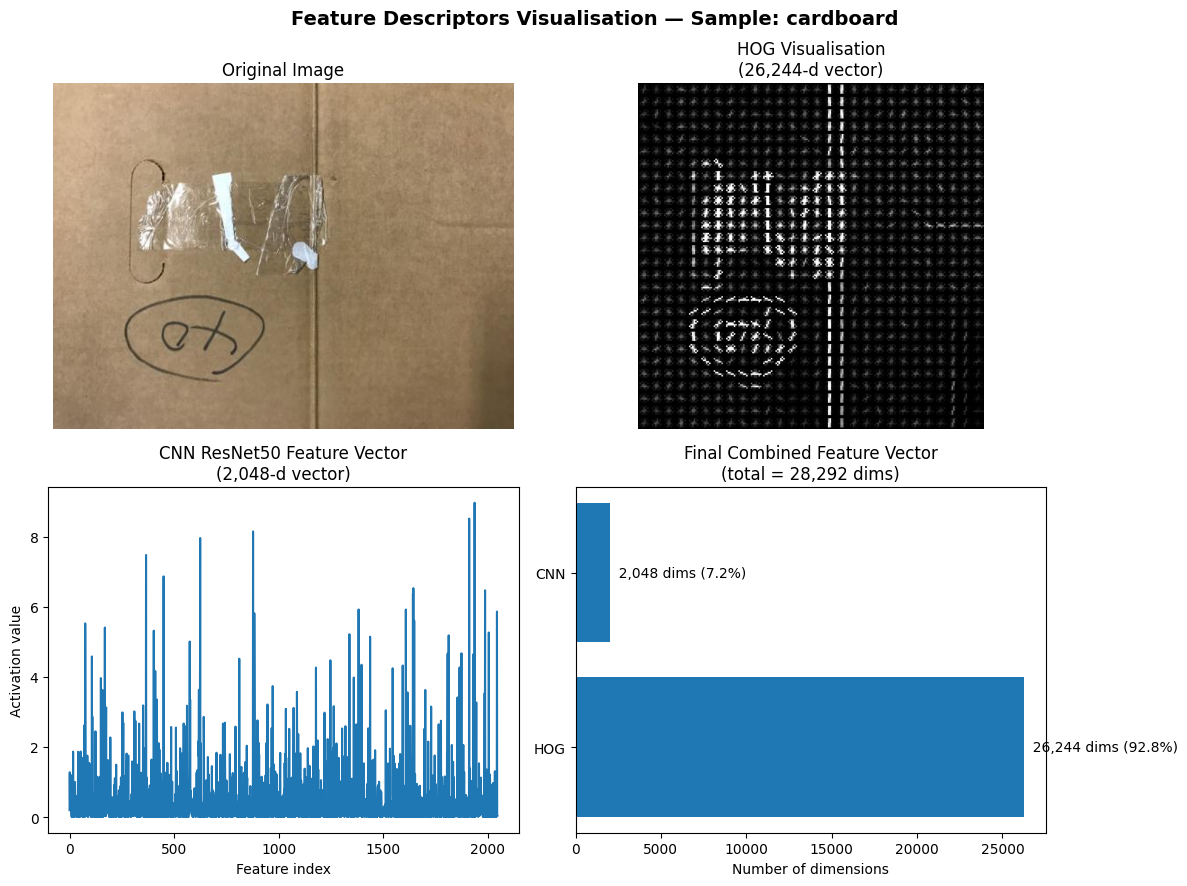

Figure saved to: d:\Material-Stream-Identification-System - ML\features\hog_cnn_descriptor_visualisation.png


In [ ]:
# Project paths

BASE_DIR = Path.cwd().parent
DATASET_DIR = BASE_DIR / "dataset"
FEATURES_DIR = BASE_DIR / "features"
FEATURES_DIR.mkdir(parents=True, exist_ok=True)


# Settings
IMAGE_SIZE = (224, 224)

HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_BLOCK_NORM = "L2-Hys"


# Build ResNet50 feature extractor
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

cnn_model = Model(
    inputs=base_model.input,
    outputs=GlobalAveragePooling2D()(base_model.output)
)


# HOG extraction with visualisation
def extract_hog_with_visualisation(image_bgr):
    resized = cv2.resize(image_bgr, IMAGE_SIZE)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

    hog_features, hog_image = hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm=HOG_BLOCK_NORM,
        visualize=True,
        feature_vector=True
    )

    hog_image = exposure.rescale_intensity(hog_image, in_range=(0, 10))

    return hog_features.astype(np.float32), hog_image



# CNN feature extraction
def extract_cnn_features(image_bgr):
    resized = cv2.resize(image_bgr, IMAGE_SIZE)

    # ResNet50 preprocess_input expects RGB-style image array before preprocessing
    image_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

    batch = np.expand_dims(image_rgb.astype(np.float32), axis=0)
    batch = preprocess_input(batch)

    cnn_features = cnn_model.predict(batch, verbose=0)
    cnn_features = np.nan_to_num(cnn_features)

    return cnn_features.flatten().astype(np.float32)



# Pick one sample image
sample_class = "cardboard"   # Change this to glass, metal, paper, plastic, or trash
sample_dir = DATASET_DIR / sample_class

image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]

sample_paths = []
for ext in image_extensions:
    sample_paths.extend(sample_dir.glob(ext))

if len(sample_paths) == 0:
    raise FileNotFoundError(f"No images found inside: {sample_dir}")

sample_path = sample_paths[0]

image_bgr = cv2.imread(str(sample_path))
if image_bgr is None:
    raise ValueError(f"Could not read image: {sample_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


# Extract descriptors
hog_features, hog_image = extract_hog_with_visualisation(image_bgr)
cnn_features = extract_cnn_features(image_bgr)

hog_dim = hog_features.shape[0]
cnn_dim = cnn_features.shape[0]
final_dim = hog_dim + cnn_dim

print("Sample image:", sample_path)
print("HOG feature dimensions:", hog_dim)
print("CNN feature dimensions:", cnn_dim)
print("Final HOG + CNN feature dimensions:", final_dim)


# Plot descriptor visualisation figure
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

fig.suptitle(
    f"Feature Descriptors Visualisation — Sample: {sample_class}",
    fontsize=14,
    fontweight="bold"
)

# Original image
axes[0, 0].imshow(image_rgb)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# HOG visualisation
axes[0, 1].imshow(hog_image, cmap="gray")
axes[0, 1].set_title(f"HOG Visualisation\n({hog_dim:,}-d vector)")
axes[0, 1].axis("off")

# CNN feature vector plot
axes[1, 0].plot(cnn_features)
axes[1, 0].set_title(f"CNN ResNet50 Feature Vector\n({cnn_dim:,}-d vector)")
axes[1, 0].set_xlabel("Feature index")
axes[1, 0].set_ylabel("Activation value")

# Feature vector composition
descriptor_names = ["HOG", "CNN"]
descriptor_dims = [hog_dim, cnn_dim]

axes[1, 1].barh(descriptor_names, descriptor_dims)
axes[1, 1].set_title(f"Final Combined Feature Vector\n(total = {final_dim:,} dims)")
axes[1, 1].set_xlabel("Number of dimensions")

for i, value in enumerate(descriptor_dims):
    percentage = (value / final_dim) * 100
    axes[1, 1].text(
        value,
        i,
        f"  {value:,} dims ({percentage:.1f}%)",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.show()

## Extract CNN and HOG Features for All Splits


In [35]:
print("\nExtracting training CNN features...")
X_train_cnn = extract_cnn_features_from_paths(train_paths)

print("\nExtracting validation CNN features...")
X_val_cnn = extract_cnn_features_from_paths(val_paths)

print("\nExtracting test CNN features...")
X_test_cnn = extract_cnn_features_from_paths(test_paths)

print("\nExtracting training HOG features...")
X_train_hog = extract_hog_features_from_paths(train_paths)

print("\nExtracting validation HOG features...")
X_val_hog = extract_hog_features_from_paths(val_paths)

print("\nExtracting test HOG features...")
X_test_hog = extract_hog_features_from_paths(test_paths)

# The row counts must stay equal because both extractors use the same path arrays.
assert X_train_cnn.shape[0] == X_train_hog.shape[0] == len(y_train_str)
assert X_val_cnn.shape[0] == X_val_hog.shape[0] == len(y_val_str)
assert X_test_cnn.shape[0] == X_test_hog.shape[0] == len(y_test_str)

print("\nFeature extraction completed")
print(f"CNN train shape: {X_train_cnn.shape}")
print(f"HOG train shape: {X_train_hog.shape}")
print(f"CNN val shape:   {X_val_cnn.shape}")
print(f"HOG val shape:   {X_val_hog.shape}")
print(f"CNN test shape:  {X_test_cnn.shape}")
print(f"HOG test shape:  {X_test_hog.shape}")



Extracting training CNN features...


Extracting CNN: 100%|██████████| 3000/3000 [02:59<00:00, 16.73it/s]



Extracting validation CNN features...


Extracting CNN: 100%|██████████| 279/279 [00:10<00:00, 26.46it/s]



Extracting test CNN features...


...


Extracting validation HOG features...


Extracting HOG: 100%|██████████| 279/279 [00:04<00:00, 57.31it/s]



Extracting test HOG features...


Extracting HOG: 100%|██████████| 283/283 [00:05<00:00, 52.29it/s]


Feature extraction completed
CNN train shape: (3000, 2048)
HOG train shape: (3000, 26244)
CNN val shape:   (279, 2048)
HOG val shape:   (279, 26244)
CNN test shape:  (283, 2048)
HOG test shape:  (283, 26244)


## Scale and Combine the Feature Blocks

The scalers are fitted only on the training data, then reused with `transform()` for validation and test data.

The preprocessing strategy is:

- CNN block: L2 normalization.
- HOG block: standardization followed by L2 normalization.
- Final vector: concatenation of the scaled HOG block and the scaled CNN block.

This keeps the two feature groups more comparable in magnitude before the classifier receives them.


In [ ]:
print("\nScaling CNN features...")
cnn_scaler = Normalizer(norm="l2")
X_train_cnn_scaled = cnn_scaler.fit_transform(X_train_cnn).astype(np.float32)
X_val_cnn_scaled   = cnn_scaler.transform(X_val_cnn).astype(np.float32)
X_test_cnn_scaled  = cnn_scaler.transform(X_test_cnn).astype(np.float32)

print("Scaling HOG features...")
hog_standard_scaler = StandardScaler()
X_train_hog_std = hog_standard_scaler.fit_transform(X_train_hog)
X_val_hog_std   = hog_standard_scaler.transform(X_val_hog)
X_test_hog_std  = hog_standard_scaler.transform(X_test_hog)

hog_normalizer = Normalizer(norm="l2")
X_train_hog_scaled = hog_normalizer.fit_transform(X_train_hog_std).astype(np.float32)
X_val_hog_scaled   = hog_normalizer.transform(X_val_hog_std).astype(np.float32)
X_test_hog_scaled  = hog_normalizer.transform(X_test_hog_std).astype(np.float32)

print("Combining HOG + CNN scaled features...")
X_train_scaled = np.hstack([
    HOG_WEIGHT * X_train_hog_scaled,
    CNN_WEIGHT * X_train_cnn_scaled
]).astype(np.float32)

X_val_scaled = np.hstack([
    HOG_WEIGHT * X_val_hog_scaled,
    CNN_WEIGHT * X_val_cnn_scaled
]).astype(np.float32)

X_test_scaled = np.hstack([
    HOG_WEIGHT * X_test_hog_scaled,
    CNN_WEIGHT * X_test_cnn_scaled
]).astype(np.float32)

print("\nScaling and combination completed ")
print(f"X_train_cnn_scaled: {X_train_cnn_scaled.shape}")
print(f"X_train_hog_scaled: {X_train_hog_scaled.shape}")
print(f"X_train_scaled combined: {X_train_scaled.shape}")
print(f"X_val_scaled combined:   {X_val_scaled.shape}")
print(f"X_test_scaled combined:  {X_test_scaled.shape}")



Scaling CNN features...
Scaling HOG features...
Combining HOG + CNN scaled features...

Scaling and combination completed 
X_train_cnn_scaled: (3000, 2048)
X_train_hog_scaled: (3000, 26244)
X_train_scaled combined: (3000, 28292)
X_val_scaled combined:   (279, 28292)
X_test_scaled combined:  (283, 28292)


## Save Features, Labels, and Preprocessing Objects


In [ ]:
# Main feature files used by the classifier notebooks.
np.save(FEATURES_PATH / "X_train_scaled.npy", X_train_scaled)
np.save(FEATURES_PATH / "X_val_scaled.npy",   X_val_scaled)
np.save(FEATURES_PATH / "X_test_scaled.npy",  X_test_scaled)

# Class labels saved as strings for easier reading in reports and confusion matrices.
np.save(FEATURES_PATH / "y_train.npy", y_train_str)
np.save(FEATURES_PATH / "y_val.npy",   y_val_str)
np.save(FEATURES_PATH / "y_test.npy",  y_test_str)

# Encoded labels are saved separately in case another model needs numeric targets.
np.save(FEATURES_PATH / "y_train_encoded.npy", y_train_encoded)
np.save(FEATURES_PATH / "y_val_encoded.npy",   y_val_encoded)
np.save(FEATURES_PATH / "y_test_encoded.npy",  y_test_encoded)
np.save(FEATURES_PATH / "label_classes.npy", label_encoder.classes_)

# Individual feature blocks are kept to support ablation and comparison experiments.
np.save(FEATURES_PATH / "X_train_cnn_scaled.npy", X_train_cnn_scaled)
np.save(FEATURES_PATH / "X_val_cnn_scaled.npy",   X_val_cnn_scaled)
np.save(FEATURES_PATH / "X_test_cnn_scaled.npy",  X_test_cnn_scaled)

np.save(FEATURES_PATH / "X_train_hog_scaled.npy", X_train_hog_scaled)
np.save(FEATURES_PATH / "X_val_hog_scaled.npy",   X_val_hog_scaled)
np.save(FEATURES_PATH / "X_test_hog_scaled.npy",  X_test_hog_scaled)

np.save(FEATURES_PATH / "X_train_hog_cnn_scaled.npy", X_train_scaled)
np.save(FEATURES_PATH / "X_val_hog_cnn_scaled.npy",   X_val_scaled)
np.save(FEATURES_PATH / "X_test_hog_cnn_scaled.npy",  X_test_scaled)

# Store all preprocessing objects required to reproduce the same feature vector later.
combined_scaler_bundle = {
    "cnn_scaler": cnn_scaler,
    "hog_standard_scaler": hog_standard_scaler,
    "hog_normalizer": hog_normalizer,
    "hog_weight": HOG_WEIGHT,
    "cnn_weight": CNN_WEIGHT,
}

joblib.dump(combined_scaler_bundle, MODELS_PATH / "scaler.pkl")
joblib.dump(label_encoder, MODELS_PATH / "label_encoder.pkl")

print("Saved final features, labels, and scalers")
print("Main classifier input:")
print("  ../features/X_train_scaled.npy")
print("  ../features/X_val_scaled.npy")
print("  ../features/X_test_scaled.npy")
print("  ../features/y_train.npy")
print("  ../features/y_val.npy")
print("  ../features/y_test.npy")


Saved final features, labels, and scalers
Main classifier input:
  ../features/X_train_scaled.npy
  ../features/X_val_scaled.npy
  ../features/X_test_scaled.npy
  ../features/y_train.npy
  ../features/y_val.npy
  ../features/y_test.npy


## Export the Feature Configuration


In [ ]:
feature_config = {
    "feature_type": "HOG + CNN",
    "final_compatibility_files": {
        "X_train_scaled": "../features/X_train_scaled.npy",
        "X_val_scaled": "../features/X_val_scaled.npy",
        "X_test_scaled": "../features/X_test_scaled.npy",
        "labels": "../features/y_train.npy / y_val.npy / y_test.npy"
    },
    "cnn": {
        "model": "ResNet50",
        "weights": "imagenet",
        "include_top": False,
        "pooling": "GlobalAveragePooling2D",
        "image_size": list(CNN_IMAGE_SIZE),
        "raw_dim": int(X_train_cnn.shape[1]),
        "scaling": "L2 normalization fitted on the training CNN features only"
    },
    "hog": {
        "image_size": list(HOG_IMAGE_SIZE),
        "params": HOG_PARAMS,
        "raw_dim": int(X_train_hog.shape[1]),
        "scaling": "StandardScaler fitted on training HOG features, followed by L2 normalization"
    },
    "combined": {
        "hog_weight": HOG_WEIGHT,
        "cnn_weight": CNN_WEIGHT,
        "combined_dim": int(X_train_scaled.shape[1]),
        "layout": "[HOG_scaled | CNN_scaled]"
    },
    "paths": {
        "train": str(TRAIN_PATH),
        "val": str(VAL_PATH),
        "test": str(TEST_PATH),
        "features": str(FEATURES_PATH),
        "models": str(MODELS_PATH)
    },
    "classes": label_encoder.classes_.tolist(),
    "note": "Training data is used to fit the preprocessing objects. Validation and test data are transformed only."
}

with open(FEATURES_PATH / "feature_config.json", "w") as f:
    json.dump(feature_config, f, indent=4)

with open(FEATURES_PATH / "hog_cnn_feature_config.json", "w") as f:
    json.dump(feature_config, f, indent=4)

print("Saved feature_config.json")
print("Saved hog_cnn_feature_config.json")


Saved feature_config.json
Saved hog_cnn_feature_config.json


## Sanity Check After Saving


In [ ]:
X_check = np.load(FEATURES_PATH / "X_train_scaled.npy")
y_check = np.load(FEATURES_PATH / "y_train.npy", allow_pickle=True)
scaler_bundle = joblib.load(MODELS_PATH / "scaler.pkl")

print("X_train_scaled:", X_check.shape)
print("y_train:", y_check.shape)
print("Scaler bundle keys:", list(scaler_bundle.keys()))


X_train_scaled: (3000, 28292)
y_train: (3000,)
Scaler bundle keys: ['cnn_scaler', 'hog_standard_scaler', 'hog_normalizer', 'hog_weight', 'cnn_weight']


## Optional Visual Check for HOG


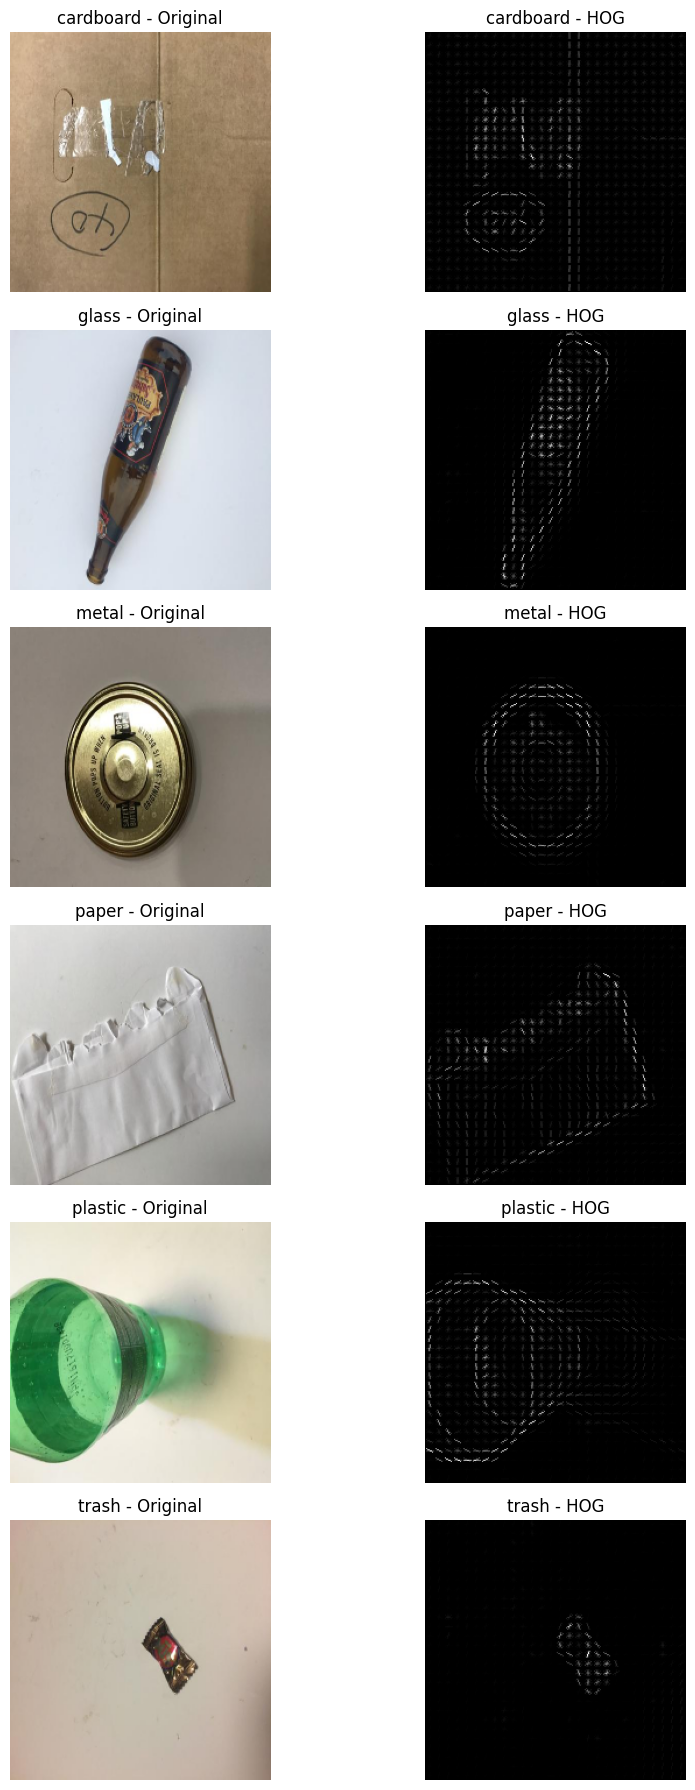

In [ ]:
# This visualization is only for checking and reporting the HOG representation.

def show_hog_examples(dataset_path: Path, max_classes: int = 6):
    class_dirs = sorted([p for p in dataset_path.iterdir() if p.is_dir()])[:max_classes]
    if not class_dirs:
        print("No class folders found.")
        return

    plt.figure(figsize=(10, len(class_dirs) * 3))
    plot_index = 1

    for class_dir in class_dirs:
        img_files = sorted([p for p in class_dir.iterdir() if p.suffix.lower() in IMG_EXTENSIONS])
        if not img_files:
            continue

        img_bgr = cv2.imread(str(img_files[0]))
        if img_bgr is None:
            continue

        img_resized = cv2.resize(img_bgr, (HOG_IMAGE_SIZE[1], HOG_IMAGE_SIZE[0]))
        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

        _, hog_image = hog_visualizer(
            gray,
            orientations=HOG_PARAMS["orientations"],
            pixels_per_cell=HOG_PARAMS["pixels_per_cell"],
            cells_per_block=HOG_PARAMS["cells_per_block"],
            block_norm=HOG_PARAMS["block_norm"],
            visualize=True,
            feature_vector=True
        )

        plt.subplot(len(class_dirs), 2, plot_index)
        plt.imshow(cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))
        plt.title(f"{class_dir.name} - Original")
        plt.axis("off")

        plt.subplot(len(class_dirs), 2, plot_index + 1)
        plt.imshow(hog_image, cmap="gray")
        plt.title(f"{class_dir.name} - HOG")
        plt.axis("off")

        plot_index += 2

    plt.tight_layout()
    plt.show()

# Run this when report figures are needed.
show_hog_examples(TRAIN_PATH)


## Deployment Notes for the Camera App


In [ ]:
print("""
Camera app preprocessing rule for the HOG + CNN feature set:

This notebook saves the preprocessing objects in one file only:
       models/scaler.pkl

This file is a preprocessing bundle. It contains the saved scalers, normalizer,
and feature weights needed to process live camera frames in the same way used
during training.

The label encoder is saved separately:
       models/label_encoder.pkl

Since the camera app is inside the src folder, load the files using the project
root path instead of depending on the current working directory:

       from pathlib import Path
       import joblib

       BASE_DIR = Path(__file__).resolve().parent.parent

       scaler_bundle = joblib.load(BASE_DIR / "models" / "scaler.pkl")
       label_encoder = joblib.load(BASE_DIR / "models" / "label_encoder.pkl")

       cnn_scaler = scaler_bundle["cnn_scaler"]
       hog_standard_scaler = scaler_bundle["hog_standard_scaler"]
       hog_normalizer = scaler_bundle["hog_normalizer"]

       hog_weight = scaler_bundle["hog_weight"]
       cnn_weight = scaler_bundle["cnn_weight"]

For each camera frame:

1) Extract the CNN features using the same ResNet50 feature extractor used
   during feature extraction.

       # The CNN batch must be prepared with the same image size and preprocessing
       # used during training.
       cnn_raw = cnn_model.predict(preprocess_input(batch), verbose=0)
       cnn_scaled = cnn_scaler.transform(cnn_raw)

2) Extract the HOG features using the same HOG settings used during training.

       hog_raw = extract_hog_features_from_bgr(frame_bgr).reshape(1, -1)
       hog_std = hog_standard_scaler.transform(hog_raw)
       hog_scaled = hog_normalizer.transform(hog_std)

3) Combine the scaled features using the same order used during training:

       final_feature = np.hstack([
           hog_weight * hog_scaled,
           cnn_weight * cnn_scaled
       ])

   Important: the feature order must stay HOG first, then CNN.

4) Send final_feature to the trained classifier, such as the saved SVM or KNN model.

5) Use label_encoder.pkl only after prediction if the predicted numeric label
   needs to be converted back to the original class name.

Important:
The camera app must only use transform().
It must not call fit(), fit_transform(), or create new scalers during prediction.
""")


Camera app preprocessing rule for the HOG + CNN feature set:

This notebook saves the preprocessing objects in one file only:
       models/scaler.pkl

This file is a preprocessing bundle. It contains the saved scalers, normalizer,
and feature weights needed to process live camera frames in the same way used
during training.

The label encoder is saved separately:
       models/label_encoder.pkl

Since the camera app is inside the src folder, load the files using the project
root path instead of depending on the current working directory:

       from pathlib import Path
       import joblib

       BASE_DIR = Path(__file__).resolve().parent.parent

       scaler_bundle = joblib.load(BASE_DIR / "models" / "scaler.pkl")
       label_encoder = joblib.load(BASE_DIR / "models" / "label_encoder.pkl")

       cnn_scaler = scaler_bundle["cnn_scaler"]
       hog_standard_scaler = scaler_bundle["hog_standard_scaler"]
       hog_normalizer = scaler_bundle["hog_normalizer"]

       hog_weight = 

## Notebook Completion Summary


In [ ]:
print(f"CNN raw dimension: {X_train_cnn.shape[1]}")
print(f"HOG raw dimension: {X_train_hog.shape[1]}")
print(f"Final combined dimension: {X_train_scaled.shape[1]}")
print(f"Train samples: {len(y_train_str)}")
print(f"Val samples:   {len(y_val_str)}")
print(f"Test samples:  {len(y_test_str)}")
print("\nUse these files in the classifier notebooks:")
print("  X_train = np.load('../features/X_train_scaled.npy')")
print("  X_val   = np.load('../features/X_val_scaled.npy')")
print("  X_test  = np.load('../features/X_test_scaled.npy')")
print("  y_train = np.load('../features/y_train.npy', allow_pickle=True)")
print("  y_val   = np.load('../features/y_val.npy', allow_pickle=True)")
print("  y_test  = np.load('../features/y_test.npy', allow_pickle=True)")


CNN raw dimension: 2048
HOG raw dimension: 26244
Final combined dimension: 28292
Train samples: 3000
Val samples:   279
Test samples:  283

Use these files in the classifier notebooks:
  X_train = np.load('../features/X_train_scaled.npy')
  X_val   = np.load('../features/X_val_scaled.npy')
  X_test  = np.load('../features/X_test_scaled.npy')
  y_train = np.load('../features/y_train.npy', allow_pickle=True)
  y_val   = np.load('../features/y_val.npy', allow_pickle=True)
  y_test  = np.load('../features/y_test.npy', allow_pickle=True)
